Implement K-Means clustering on Iris.csv dataset. Determine the number of clusters using the elbow method. Dataset Link: https://www.kaggle.com/datasets/uciml/iris

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [ ]:
df=pd.read_csv('/content/Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
x=df[['SepalLengthCm','SepalWidthCm','PetalLengthCm','PetalWidthCm']]

In [ ]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x)

In [ ]:
wcss=[]
k_values=list(range(1,11))

for k in k_values:
  Kmeans=KMeans(n_clusters=k,random_state=42)
  Kmeans.fit(x_scaled)
  wcss.append(Kmeans.inertia_)

wcss_table = pd.DataFrame({
    "Number of Clusters (K)": k_values,
    "WCSS Value": wcss
})

print(wcss_table)

   Number of Clusters (K)  WCSS Value
0                       1  600.000000
1                       2  223.732006
2                       3  192.037174
3                       4  114.682216
4                       5   91.295445
5                       6   81.760261
6                       7   80.982381
7                       8   68.086239
8                       9   59.385289
9                      10   52.989997


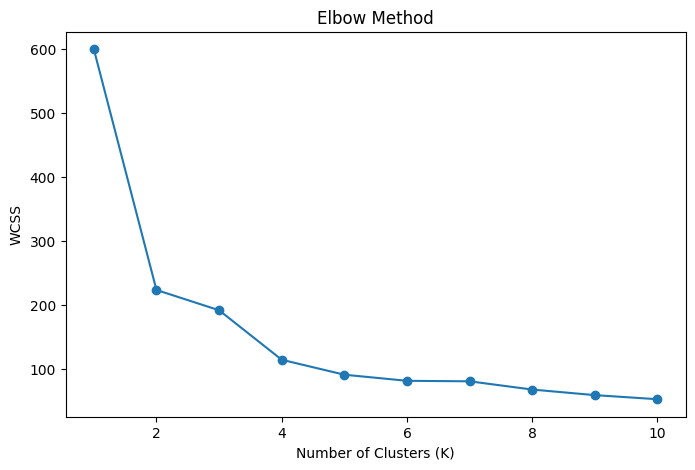

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()


In [ ]:
sil_scores=[]
k_range=list(range(2,11))

for k in k_range:
  kmeans=KMeans(n_clusters=k,random_state=42)
  lables=kmeans.fit_predict(x_scaled)
  sil=silhouette_score(x_scaled,lables)
  sil_scores.append(sil)

sil_table = pd.DataFrame({
    "Number of Clusters (K)": k_range,
    "Silhouette Score": sil_scores
})

print(sil_table)

   Number of Clusters (K)  Silhouette Score
0                       2          0.580184
1                       3          0.478724
2                       4          0.387247
3                       5          0.347265
4                       6          0.336223
5                       7          0.268562
6                       8          0.315682
7                       9          0.299142
8                      10          0.321103


In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_pred = kmeans.fit_predict(x_scaled)

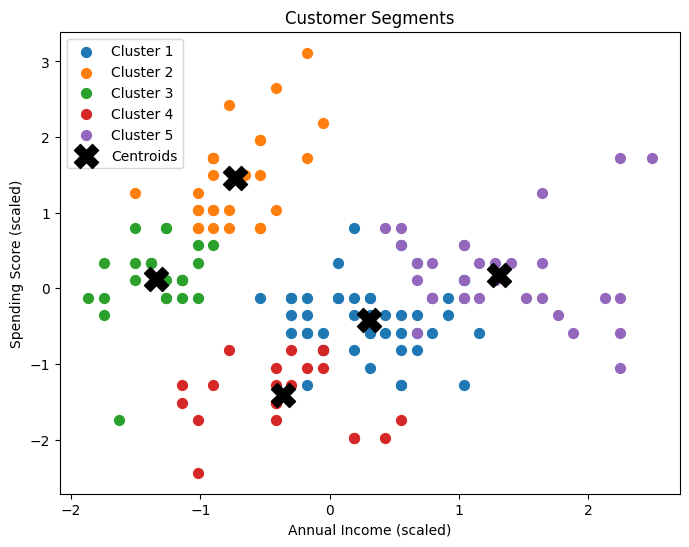

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(x_scaled[y_pred==0,0], x_scaled[y_pred==0,1], s=50, label="Cluster 1")
plt.scatter(x_scaled[y_pred==1,0], x_scaled[y_pred==1,1], s=50, label="Cluster 2")
plt.scatter(x_scaled[y_pred==2,0], x_scaled[y_pred==2,1], s=50, label="Cluster 3")
plt.scatter(x_scaled[y_pred==3,0], x_scaled[y_pred==3,1], s=50, label="Cluster 4")
plt.scatter(x_scaled[y_pred==4,0], x_scaled[y_pred==4,1], s=50, label="Cluster 5")

plt.scatter(kmeans.cluster_centers_[:,0],
            kmeans.cluster_centers_[:,1],
            s=300, c='black', marker='X', label="Centroids")

plt.title("Customer Segments")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()
plt.show()